In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("health_dataset_ml.csv")

print(df.head())

   Age   BMI  BloodPressure  Glucose  Cholesterol  ExerciseHoursPerWeek  \
0   58  19.7            124      165          197                   5.2   
1   48  29.6            154      182          186                   6.7   
2   34  25.5            136      131          158                   2.3   
3   62  20.1             92      121          248                   3.9   
4   27  26.4             90       81          197                   4.0   

   DiabetesRiskScore  
0              14.50  
1              16.68  
2              14.45  
3              13.90  
4              12.08  


In [5]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   50 non-null     int64  
 1   BMI                   50 non-null     float64
 2   BloodPressure         50 non-null     int64  
 3   Glucose               50 non-null     int64  
 4   Cholesterol           50 non-null     int64  
 5   ExerciseHoursPerWeek  50 non-null     float64
 6   DiabetesRiskScore     50 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 2.9 KB
None
             Age        BMI  BloodPressure    Glucose  Cholesterol  \
count  50.000000  50.000000      50.000000   50.00000    50.000000   
mean   43.680000  25.992000     124.020000  149.88000   215.580000   
std    13.890887   5.224153      20.872294   40.44126    39.758501   
min    21.000000  18.100000      90.000000   71.00000   153.000000   
25%    33.250000  21.325000     106.000000  1

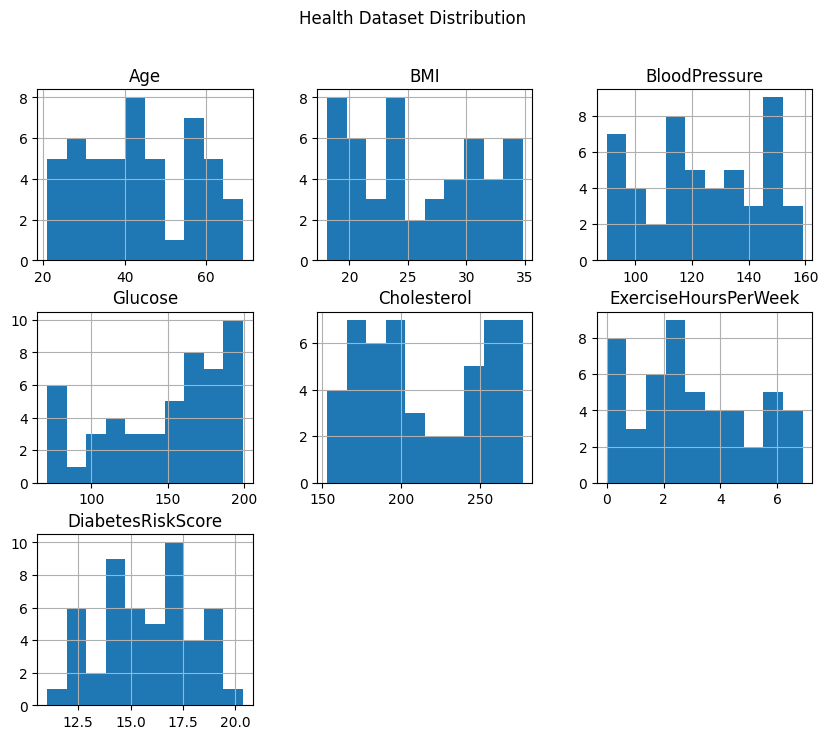

In [6]:
df.hist(figsize=(10,8))
plt.suptitle("Health Dataset Distribution")
plt.show()

In [7]:
X = df[['Age','BMI','BloodPressure','Glucose','Cholesterol','ExerciseHoursPerWeek']]
y = df['DiabetesRiskScore']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9999952094765486
RMSE: 0.00400416361939818


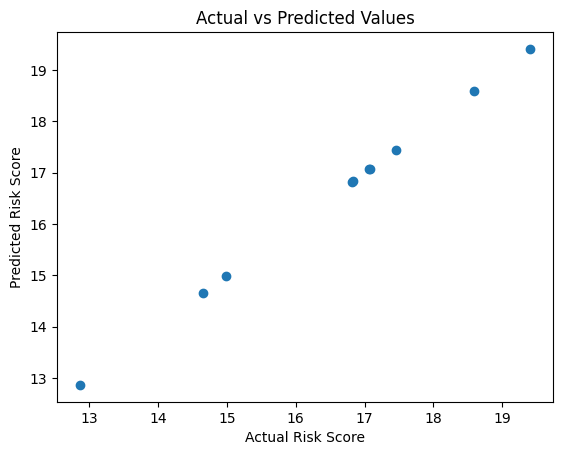

In [13]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")

plt.title("Actual vs Predicted Values")

plt.show()

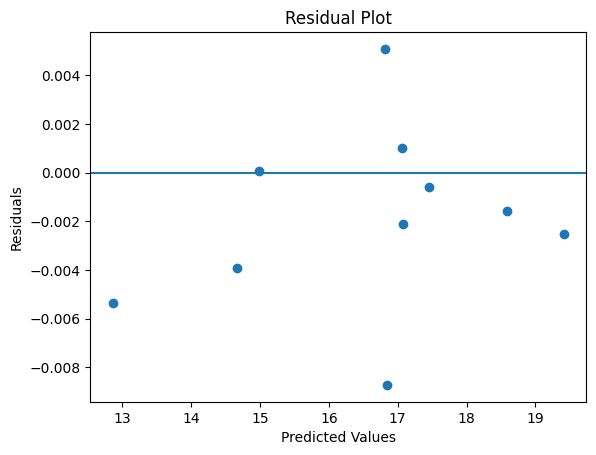

In [14]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

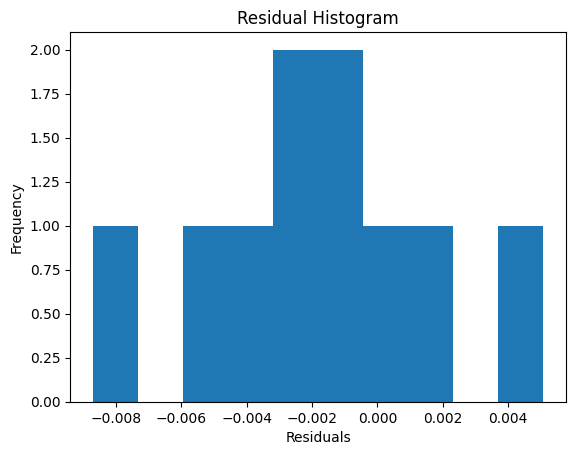

In [15]:
plt.hist(residuals, bins=10)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Residual Histogram")

plt.show()

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(feature_importance)

                Feature  Coefficient
0                   Age     0.412944
1                   BMI     1.009824
2         BloodPressure     0.433480
3               Glucose     1.191954
4           Cholesterol     0.577297
5  ExerciseHoursPerWeek    -0.610433


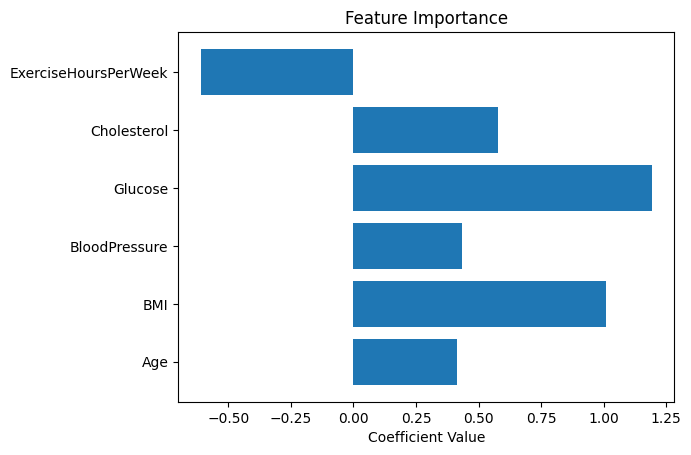

In [17]:
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

plt.title("Feature Importance")

plt.xlabel("Coefficient Value")

plt.show()